# CHronoZ | Redundancy map

## Summary

The saved run screens **351 pairs** among **27 monthly series**. **7 candidate pairs** connect **10 series** under the explicit Pearson/rank thresholds. Four other strong Pearson pairs do not pass the rank/sign screen. No dataset is removed; candidates require economic review before any variable selection.

Charts and tables use full dataset titles. Missing months remain missing. This summary describes the saved run; the final summary cell recomputes the results when inputs or parameters change.

## Context & Methods

Which transformed monthly series have strong contemporaneous overlap, and which candidates also show rank-based agreement?

### Assumptions and scope

- Native monthly series only, selected by both expected and inferred frequency. Weekly and quarterly exclusions are displayed.
- Use the same explicit percentage-change / first-difference registry as the initial correlation notebook. Rates use percentage-point changes; hours use hour changes.
- Changes require consecutive calendar months. Dropped observations remain gaps; a September-November move is never treated as one month.
- No re-cleaning, interpolation, filling, frequency conversion, model training, or automatic variable removal.
- Correlation is descriptive co-movement. It does not establish causality or predictive value. No release-calendar/vintage data is available, so observation dates are not information-availability dates.
- Candidate rule: at least 60 paired observations, absolute Pearson >= 0.80, absolute Spearman >= 0.60, and matching signs. Thresholds are editable screening choices, not a statistical proof of redundancy.
- Each pair uses its own history. Negative correlations can indicate inverse overlap. No clustering or representative-variable selection is performed.

**Inputs:** `data/cleaned/series_metadata.csv`, the referenced cleaned series, and `data/audit/data_cleaning_audit.csv`.
All inputs are read directly; this notebook does not depend on another notebook being run.
**Outputs:** `outputs/redundancy/`. Full titles are used in reports; source IDs remain internal.
**Environment:** Python with `requirements-notebook.txt`; Restart Kernel and Run All from the project or notebook folder.

### Setup and editable parameters

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import textwrap
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

MIN_PERIODS = 60
root_candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in root_candidates if (p / 'data/cleaned/series_metadata.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Run from the CHronoZ project or its notebook directory.')
CLEAN = ROOT / 'data/cleaned'
OUT = ROOT / 'outputs/redundancy'
OUT.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_rows', 40)
pd.set_option('display.max_columns', 10)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda value: f'{value:.4f}')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11,
                     'axes.titlesize': 16, 'figure.facecolor': 'white'})


# End-user labels; analysis keys and source filenames remain series IDs.
DISPLAY_NAMES = {'INDPRO': 'Industrial Production', 'IPMAN': 'Manufacturing Production', 'PCEC96': 'Real Personal Consumption Expenditure', 'W875RX1': 'Real Personal Income excluding transfers', 'RPI': 'Real Personal Income', 'RRSFS': 'Real Retail & Food Services Sales', 'HOUST': 'Housing Starts', 'PERMIT': 'Building Permits', 'PAYEMS': 'Nonfarm Payroll Employment', 'UNRATE': 'Unemployment Rate', 'AWHAETP': 'Average Weekly Hours — Total Private', 'AWHMAN': 'Average Weekly Hours — Manufacturing', 'JTSJOL': 'Job Openings', 'CIVPART': 'Labor Force Participation Rate', 'CES0500000003': 'Average Hourly Earnings — Total Private', 'CPIAUCSL': 'CPI All Items', 'CPILFESL': 'Core CPI', 'PCEPI': 'PCE Price Index', 'PCEPILFE': 'Core PCE Price Index', 'PPIFID': 'Producer Prices — Final Demand', 'PPIACO': 'Producer Prices — All Commodities', 'BUSLOANS': 'Commercial & Industrial Loans', 'TOTALSL': 'Consumer Credit', 'FEDFUNDS': 'Federal Funds Rate', 'TOTRESNS': 'Total Bank Reserves', 'M2SL': 'M2 Money Supply', 'TCU': 'Total Capacity Utilization'}

def report_frame(frame):
    readable = frame.copy()
    if 'series_id' in readable:
        if 'name' in readable:
            readable = readable.drop(columns='name')
        readable['series_id'] = readable['series_id'].map(lambda sid: DISPLAY_NAMES.get(sid, sid))
    for column in ['variable_1', 'variable_2']:
        if column in readable:
            readable[column] = readable[column].map(lambda sid: DISPLAY_NAMES.get(sid, sid))
    category_names = {'growth_activity': 'Growth / Activity', 'labor': 'Labor',
                      'inflation': 'Inflation', 'credit': 'Credit',
                      'policy_liquidity': 'Policy / Liquidity', 'external_structural': 'External / Structural'}
    for column in ['category', 'category_1', 'category_2']:
        if column in readable:
            readable[column] = readable[column].replace(category_names)
    if 'transformation' in readable:
        readable['transformation'] = readable['transformation'].replace({
            'percent_change_1m': 'One-month percentage change',
            'first_difference_1m': 'One-month first difference'})
    readable = readable.rename(index=DISPLAY_NAMES, columns=DISPLAY_NAMES)
    headers = {'series_id': 'Dataset', 'variable_1': 'Dataset 1', 'variable_2': 'Dataset 2',
               'category_1': 'Category 1', 'category_2': 'Category 2'}
    readable = readable.rename(columns={c: headers.get(c, c.replace('_', ' ').capitalize())
                                       for c in readable.columns if c not in DISPLAY_NAMES.values()})
    return readable

def display_report(frame):
    readable = report_frame(frame)
    display(readable.style.hide(axis='index').format(precision=4, na_rep='Unavailable')
            .set_properties(**{'text-align': 'left', 'white-space': 'normal', 'max-width': '280px'})
            .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

input_hashes = {}
def track(path):
    input_hashes[path.relative_to(ROOT).as_posix()] = hashlib.sha256(path.read_bytes()).hexdigest()

def save_table(frame, filename, index=True):
    report_frame(frame).to_csv(OUT / filename, index=index, date_format='%Y-%m-%d')

print(f'Inputs: {CLEAN}')
print(f'Outputs: {OUT}')
print(f'Minimum pairwise sample: {MIN_PERIODS} months')

PEARSON_THRESHOLD = 0.80
SPEARMAN_THRESHOLD = 0.60

from itertools import combinations
from scipy.stats import pearsonr, spearmanr
SIGNED_COLORS = LinearSegmentedColormap.from_list('chronoz_signed', ['#2166AC', '#F7F7F7', '#B35806'])
SIGNED_COLORS.set_bad('#D5D8DC')

def pair_title(first, second):
    return DISPLAY_NAMES[first] + ' / ' + DISPLAY_NAMES[second]

def save_figure(fig, filename):
    fig.savefig(OUT / filename, dpi=140, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close(fig)

def finish(summary, parameters):
    for relative, fingerprint in input_hashes.items():
        assert hashlib.sha256((ROOT / relative).read_bytes()).hexdigest() == fingerprint, relative
    provenance = {'executed_utc': datetime.now(timezone.utc).isoformat(), 'parameters': parameters,
                  'source_hashes_sha256': input_hashes, 'series_display_names': DISPLAY_NAMES,
                  'versions': {'python': platform.python_version(), 'pandas': pd.__version__,
                               'numpy': np.__version__, 'matplotlib': matplotlib.__version__}}
    (OUT / 'provenance.json').write_text(json.dumps(provenance, indent=2), encoding='utf-8')
    (OUT / 'summary.json').write_text(json.dumps(summary, indent=2, default=str), encoding='utf-8')
    display(Markdown('\n'.join(f'- **{key.replace("_", " ").capitalize()}:** {value}' for key, value in summary.items())))
    print(f'Input hashes verified unchanged. Exports: {OUT}')

Inputs: C:\Users\HYPE AMD\Desktop\CHronoZ-Economic-Modelling\data\cleaned
Outputs: C:\Users\HYPE AMD\Desktop\CHronoZ-Economic-Modelling\outputs\redundancy
Minimum pairwise sample: 60 months


## Data

### Select monthly inputs and disclose exclusions

In [2]:
meta_path = CLEAN / 'series_metadata.csv'
audit_path = ROOT / 'data/audit/data_cleaning_audit.csv'
track(meta_path)
track(audit_path)
metadata = pd.read_csv(meta_path)
audit = pd.read_csv(audit_path)
DISPLAY_NAMES = {**audit.set_index('series_id')['name'].to_dict(), **DISPLAY_NAMES}
assert len(set(DISPLAY_NAMES.values())) == len(DISPLAY_NAMES)
required = {'series_id', 'name', 'category', 'expected_frequency', 'inferred_frequency', 'clean_file'}
assert required.issubset(metadata.columns)
assert metadata.series_id.is_unique and audit.series_id.is_unique
assert metadata[list(required)].notna().all().all()
audit_lookup = audit.set_index('series_id')
assert set(metadata.series_id).issubset(audit_lookup.index)
assert audit_lookup.loc[metadata.series_id, 'status'].ne('FAILED').all()

monthly_mask = metadata.expected_frequency.eq('monthly') & metadata.inferred_frequency.eq('monthly')
monthly_metadata = metadata.loc[monthly_mask].copy()
excluded_frequency = metadata.loc[~monthly_mask, ['series_id', 'expected_frequency', 'inferred_frequency']].copy()
excluded_frequency['reason'] = excluded_frequency.apply(
    lambda r: f'Native {r.expected_frequency}; outside monthly scope' if r.expected_frequency != 'monthly'
    else f'Frequency disagreement: inferred {r.inferred_frequency}', axis=1)
print(f'Monthly variables selected: {len(monthly_metadata)}')
display_report(excluded_frequency)
save_table(excluded_frequency, 'excluded_frequency.csv', index=False)
failed = audit.loc[audit.status.eq('FAILED'), ['series_id', 'error']]
if not failed.empty:
    print('Unavailable after cleaning:')
    display_report(failed)
source_warnings = audit.loc[audit.status.eq('WARNING'), ['series_id', 'warning']]
print('Existing cleaning warnings (retained, not repaired here):')
display_report(source_warnings)

Monthly variables selected: 27


Dataset,Expected frequency,Inferred frequency,Reason
Initial Claims,weekly,weekly,Native weekly; outside monthly scope
SLOOS: Banks Tightening C&I Lending Standards,quarterly,quarterly,Native quarterly; outside monthly scope
SLOOS: Stronger Demand for C&I Loans,quarterly,quarterly,Native quarterly; outside monthly scope
Delinquency Rate on Business Loans,quarterly,quarterly,Native quarterly; outside monthly scope
Reserve Balances with Federal Reserve Banks,weekly,weekly,Native weekly; outside monthly scope
Federal Reserve Total Assets,weekly,weekly,Native weekly; outside monthly scope
Real Exports of Goods and Services,quarterly,quarterly,Native quarterly; outside monthly scope
Real Imports of Goods and Services,quarterly,quarterly,Native quarterly; outside monthly scope
Nonfarm Business Sector Labor Productivity,quarterly,quarterly,Native quarterly; outside monthly scope


Existing cleaning warnings (retained, not repaired here):


Dataset,Warning
Real Retail & Food Services Sales,missing_value_rows_removed=1; Suspicious gaps=1
Unemployment Rate,missing_value_rows_removed=1; Suspicious gaps=1
Labor Force Participation Rate,missing_value_rows_removed=1; Suspicious gaps=1
CPI All Items,missing_value_rows_removed=1; Suspicious gaps=1
Core CPI,missing_value_rows_removed=1; Suspicious gaps=1


### Load and validate cleaned series

In [3]:
monthly_series = {}
for row in monthly_metadata.itertuples(index=False):
    # Metadata can contain Windows separators; allow reruns on other platforms.
    relative = Path(row.clean_file.replace(chr(92), '/'))
    path = (ROOT / relative).resolve()
    assert path.is_relative_to(CLEAN.resolve()) and path.is_file(), f'Invalid clean path: {row.series_id}'
    track(path)
    frame = pd.read_csv(path, parse_dates=['date'])
    assert list(frame.columns) == ['date', 'value'], row.series_id
    assert pd.api.types.is_datetime64_any_dtype(frame.date), row.series_id
    assert frame.date.notna().all() and frame.date.is_unique, f'Invalid/duplicate dates: {row.series_id}'
    assert frame.date.is_monotonic_increasing, f'Unsorted dates: {row.series_id}'
    assert frame.date.dt.is_month_start.all(), f'Non-month-start dates require review: {row.series_id}'
    assert frame.date.dt.to_period('M').is_unique, f'Multiple rows per month: {row.series_id}'
    assert pd.api.types.is_numeric_dtype(frame.value), row.series_id
    assert np.isfinite(frame.value.to_numpy()).all(), f'Non-finite values need cleaning: {row.series_id}'
    assert len(frame) > 0
    monthly_series[row.series_id] = frame.set_index('date').value.rename(row.series_id)

monthly_raw = pd.concat(monthly_series.values(), axis=1, join='outer').sort_index()
monthly_raw.index.name = 'date'
assert monthly_raw.columns.is_unique
save_table(monthly_raw, 'monthly_raw.csv')
print(f'Outer join: {monthly_raw.shape[0]:,} observed dates x {monthly_raw.shape[1]} monthly series')
print('Alignment NaNs mean no observed value on that date; no values were filled.')

Outer join: 1,364 observed dates x 27 monthly series
Alignment NaNs mean no observed value on that date; no values were filled.


C:\Users\HYPEAM~1\AppData\Local\Temp\ipykernel_19836\3450816514.py:20: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  monthly_raw = pd.concat(monthly_series.values(), axis=1, join='outer').sort_index()


### Native data coverage

In [4]:
availability = pd.DataFrame([
    {'series_id': sid, 'start_date': s.first_valid_index(), 'end_date': s.last_valid_index(),
     'observations': int(s.notna().sum())}
    for sid, s in monthly_series.items()
])
display_report(availability)
save_table(availability, 'monthly_availability.csv', index=False)

common_intersection_start = availability.start_date.max()
common_intersection_end = availability.end_date.min()
complete_months = monthly_raw.dropna(how='any').index
print(f'Common coverage window if every series were required: {common_intersection_start.date()} to {common_intersection_end.date()}')
print(f'Actual complete-case dates: {len(complete_months)}; first: {complete_months.min()}')
print('This window is NOT used to restrict the pairwise analysis.')

def observation_counts(frame):
    available = frame.notna().astype('int64')
    return available.T @ available

raw_observation_counts = observation_counts(monthly_raw)
save_table(raw_observation_counts, 'raw_pairwise_observation_counts.csv')
raw_upper = raw_observation_counts.to_numpy()[np.triu_indices(len(raw_observation_counts), k=1)]
display_report(pd.DataFrame([{'dataset': 'raw levels', 'unique_pairs': len(raw_upper),
                       'minimum_overlap': int(raw_upper.min()), 'median_overlap': float(np.median(raw_upper)),
                       'maximum_overlap': int(raw_upper.max()),
                       'pairs_below_60': int((raw_upper < MIN_PERIODS).sum())}]))

Dataset,Start date,End date,Observations
Industrial Production,1919-01-01 00:00:00,2026-07-01 00:00:00,1291
Manufacturing Production,1972-01-01 00:00:00,2026-07-01 00:00:00,655
Real Personal Consumption Expenditure,2007-01-01 00:00:00,2026-07-01 00:00:00,235
Real Personal Income excluding transfers,1959-01-01 00:00:00,2026-07-01 00:00:00,811
Real Personal Income,1959-01-01 00:00:00,2026-07-01 00:00:00,811
Real Retail & Food Services Sales,1992-01-01 00:00:00,2026-08-01 00:00:00,415
Housing Starts,1959-01-01 00:00:00,2026-08-01 00:00:00,812
Building Permits,1960-01-01 00:00:00,2026-08-01 00:00:00,800
Nonfarm Payroll Employment,1939-01-01 00:00:00,2026-08-01 00:00:00,1052
Unemployment Rate,1948-01-01 00:00:00,2026-08-01 00:00:00,943


Common coverage window if every series were required: 2009-11-01 to 2026-07-01
Actual complete-case dates: 200; first: 2009-11-01 00:00:00
This window is NOT used to restrict the pairwise analysis.


Dataset,Unique pairs,Minimum overlap,Median overlap,Maximum overlap,Pairs below 60
raw levels,351,201,715.0000,1291,0


### Explicit transformation choices

In [5]:
PERCENT_CHANGE = [
    'INDPRO', 'IPMAN', 'PCEC96', 'W875RX1', 'RPI', 'RRSFS', 'HOUST', 'PERMIT',
    'PAYEMS', 'JTSJOL', 'CES0500000003', 'CPIAUCSL', 'CPILFESL', 'PCEPI',
    'PCEPILFE', 'PPIFID', 'PPIACO', 'BUSLOANS', 'TOTALSL', 'TOTRESNS', 'M2SL',
]
FIRST_DIFFERENCE = ['UNRATE', 'AWHAETP', 'AWHMAN', 'CIVPART', 'FEDFUNDS', 'TCU']
TRANSFORMATIONS = {**dict.fromkeys(PERCENT_CHANGE, 'percent_change_1m'),
                   **dict.fromkeys(FIRST_DIFFERENCE, 'first_difference_1m')}
assert not set(PERCENT_CHANGE).intersection(FIRST_DIFFERENCE)
excluded_transformation = monthly_metadata.loc[
    ~monthly_metadata.series_id.isin(TRANSFORMATIONS), ['series_id', 'name']].copy()
excluded_transformation['reason'] = 'No explicit transformation specified'
print('Excluded from change analysis because no transformation was specified:')
display_report(excluded_transformation if len(excluded_transformation) else pd.DataFrame({'result': ['None']}))
save_table(excluded_transformation, 'excluded_transformation.csv', index=False)

transformation_registry = monthly_metadata.loc[monthly_metadata.series_id.isin(TRANSFORMATIONS),
                                                ['series_id', 'name', 'category']].copy()
transformation_registry['transformation'] = transformation_registry.series_id.map(TRANSFORMATIONS)
transformation_registry['change_unit'] = transformation_registry.series_id.map(
    lambda sid: 'percent' if sid in PERCENT_CHANGE else 'hours' if sid in ['AWHAETP', 'AWHMAN'] else 'percentage points')
save_table(transformation_registry, 'transformation_registry.csv', index=False)
display_report(transformation_registry[['series_id', 'transformation', 'change_unit']])

Excluded from change analysis because no transformation was specified:


Result
None


Dataset,Transformation,Change unit
Industrial Production,One-month percentage change,percent
Manufacturing Production,One-month percentage change,percent
Real Personal Consumption Expenditure,One-month percentage change,percent
Real Personal Income excluding transfers,One-month percentage change,percent
Real Personal Income,One-month percentage change,percent
Real Retail & Food Services Sales,One-month percentage change,percent
Housing Starts,One-month percentage change,percent
Building Permits,One-month percentage change,percent
Nonfarm Payroll Employment,One-month percentage change,percent
Unemployment Rate,One-month first difference,percentage points


### Calculate consecutive-month changes

In [6]:
def one_month_change(series, method):
    previous = series.shift(1)
    month_number = pd.Series(series.index.to_period('M').asi8, index=series.index)
    consecutive = month_number.diff().eq(1)
    paired = series.notna() & previous.notna()
    if method == 'percent_change_1m':
        positive = series.gt(0) & previous.gt(0)
        eligible = consecutive & paired & positive
        result = (100 * (series.where(eligible) / previous.where(eligible) - 1))
        invalid_positive = int((paired & consecutive & ~positive).sum())
    elif method == 'first_difference_1m':
        eligible = consecutive & paired
        result = (series - previous).where(eligible)
        invalid_positive = 0
    else:
        raise ValueError(f'Unknown transformation: {method}')
    nonfinite = result.notna() & ~np.isfinite(result)
    result = result.mask(nonfinite)
    return result, {'nonconsecutive_pairs_skipped': int((paired & ~consecutive).sum()),
                    'nonpositive_pairs_skipped': invalid_positive,
                    'nonfinite_changes_skipped': int(nonfinite.sum())}

# Small boundary check: January-to-March is not a one-month change.
probe = pd.Series([100., 120., 132.], index=pd.to_datetime(['2020-01-01', '2020-03-01', '2020-04-01']))
probe_change, _ = one_month_change(probe, 'percent_change_1m')
assert probe_change.iloc[:2].isna().all() and np.isclose(probe_change.iloc[2], 10.)
zero_probe = pd.Series([0., 2.], index=pd.to_datetime(['2020-01-01', '2020-02-01']))
assert one_month_change(zero_probe, 'percent_change_1m')[0].isna().all()

changes, transformation_checks = {}, []
for sid, series in monthly_series.items():
    if sid not in TRANSFORMATIONS:
        continue
    changes[sid], checks = one_month_change(series, TRANSFORMATIONS[sid])
    transformation_checks.append({'series_id': sid, 'transformation': TRANSFORMATIONS[sid], **checks})
monthly_change = pd.DataFrame(changes).reindex(monthly_raw.index)
transformation_checks = pd.DataFrame(transformation_checks)
save_table(monthly_change, 'monthly_change.csv')
save_table(transformation_checks, 'transformation_checks.csv', index=False)
display_report(transformation_checks.loc[transformation_checks.iloc[:, 2:].sum(axis=1).gt(0)])
print(f'Available change observations: {int(monthly_change.notna().sum().sum()):,}')

Dataset,Transformation,Nonconsecutive pairs skipped,Nonpositive pairs skipped,Nonfinite changes skipped
Real Retail & Food Services Sales,One-month percentage change,1,0,0
Unemployment Rate,One-month first difference,1,0,0
Labor Force Participation Rate,One-month first difference,1,0,0
CPI All Items,One-month percentage change,1,0,0
Core CPI,One-month percentage change,1,0,0


Available change observations: 20,728


In [7]:
series_ids = monthly_change.columns.tolist()
category_lookup = metadata.set_index('series_id').category
assert len(series_ids) >= 2
pair_ids = list(combinations(series_ids, 2))
print(f'Analysis universe: {len(series_ids)} monthly series; {len(pair_ids)} unique pairs.')

Analysis universe: 27 monthly series; 351 unique pairs.


## Results

### Pairwise redundancy screening

In [8]:
pearson_matrix = monthly_change.corr(method='pearson', min_periods=MIN_PERIODS)
spearman_matrix = monthly_change.corr(method='spearman', min_periods=MIN_PERIODS)
counts = observation_counts(monthly_change)
rows=[]
for first, second in pair_ids:
    paired=monthly_change[[first,second]].dropna()
    r=pearson_matrix.loc[first,second]
    rho=spearman_matrix.loc[first,second]
    candidate=bool(len(paired)>=MIN_PERIODS and abs(r)>=PEARSON_THRESHOLD and
                   abs(rho)>=SPEARMAN_THRESHOLD and np.sign(r)==np.sign(rho))
    rows.append({'variable_1':first, 'variable_2':second, 'pearson':r, 'spearman':rho,
                 'overlapping_observations':len(paired), 'overlap_start':paired.index.min(),
                 'overlap_end':paired.index.max(), 'category_1':category_lookup[first],
                 'category_2':category_lookup[second], 'candidate':candidate})
pairs=pd.DataFrame(rows)
candidates=pairs.loc[pairs.candidate].copy()
candidates=candidates.loc[candidates.pearson.abs().sort_values(ascending=False).index]
pearson_only=pairs.loc[pairs.pearson.abs().ge(PEARSON_THRESHOLD) & ~pairs.candidate]
save_table(pairs,'all_pairs.csv',index=False)
save_table(candidates,'redundancy_candidates.csv',index=False)
save_table(pearson_only,'pearson_only_candidates.csv',index=False)
save_table(pearson_matrix,'pearson.csv')
save_table(spearman_matrix,'spearman.csv')
save_table(counts,'pairwise_observation_counts.csv')
print(f'{len(candidates)} candidate edges; {len(pearson_only)} strong Pearson pairs fail the rank/sign screen.')
display_report(candidates.drop(columns=['overlap_start','overlap_end','candidate']))

7 candidate edges; 4 strong Pearson pairs fail the rank/sign screen.


Dataset 1,Dataset 2,Pearson,Spearman,Overlapping observations,Category 1,Category 2
Industrial Production,Total Capacity Utilization,0.9837,0.9625,714,Growth / Activity,External / Structural
Industrial Production,Manufacturing Production,0.9561,0.8962,654,Growth / Activity,Growth / Activity
Manufacturing Production,Total Capacity Utilization,0.9385,0.8565,654,Growth / Activity,External / Structural
Real Personal Consumption Expenditure,Real Retail & Food Services Sales,0.9213,0.6880,232,Growth / Activity,Growth / Activity
CPI All Items,PCE Price Index,0.9113,0.8826,808,Inflation,Inflation
PCE Price Index,Core PCE Price Index,0.8306,0.8116,810,Inflation,Inflation
Producer Prices — Final Demand,Producer Prices — All Commodities,0.8148,0.7793,201,Inflation,Inflation


### Candidate connections

An edge means the screening rule was met; it is not a causal link. Only connected series appear in the graph. All series remain in the analysis and the table below.

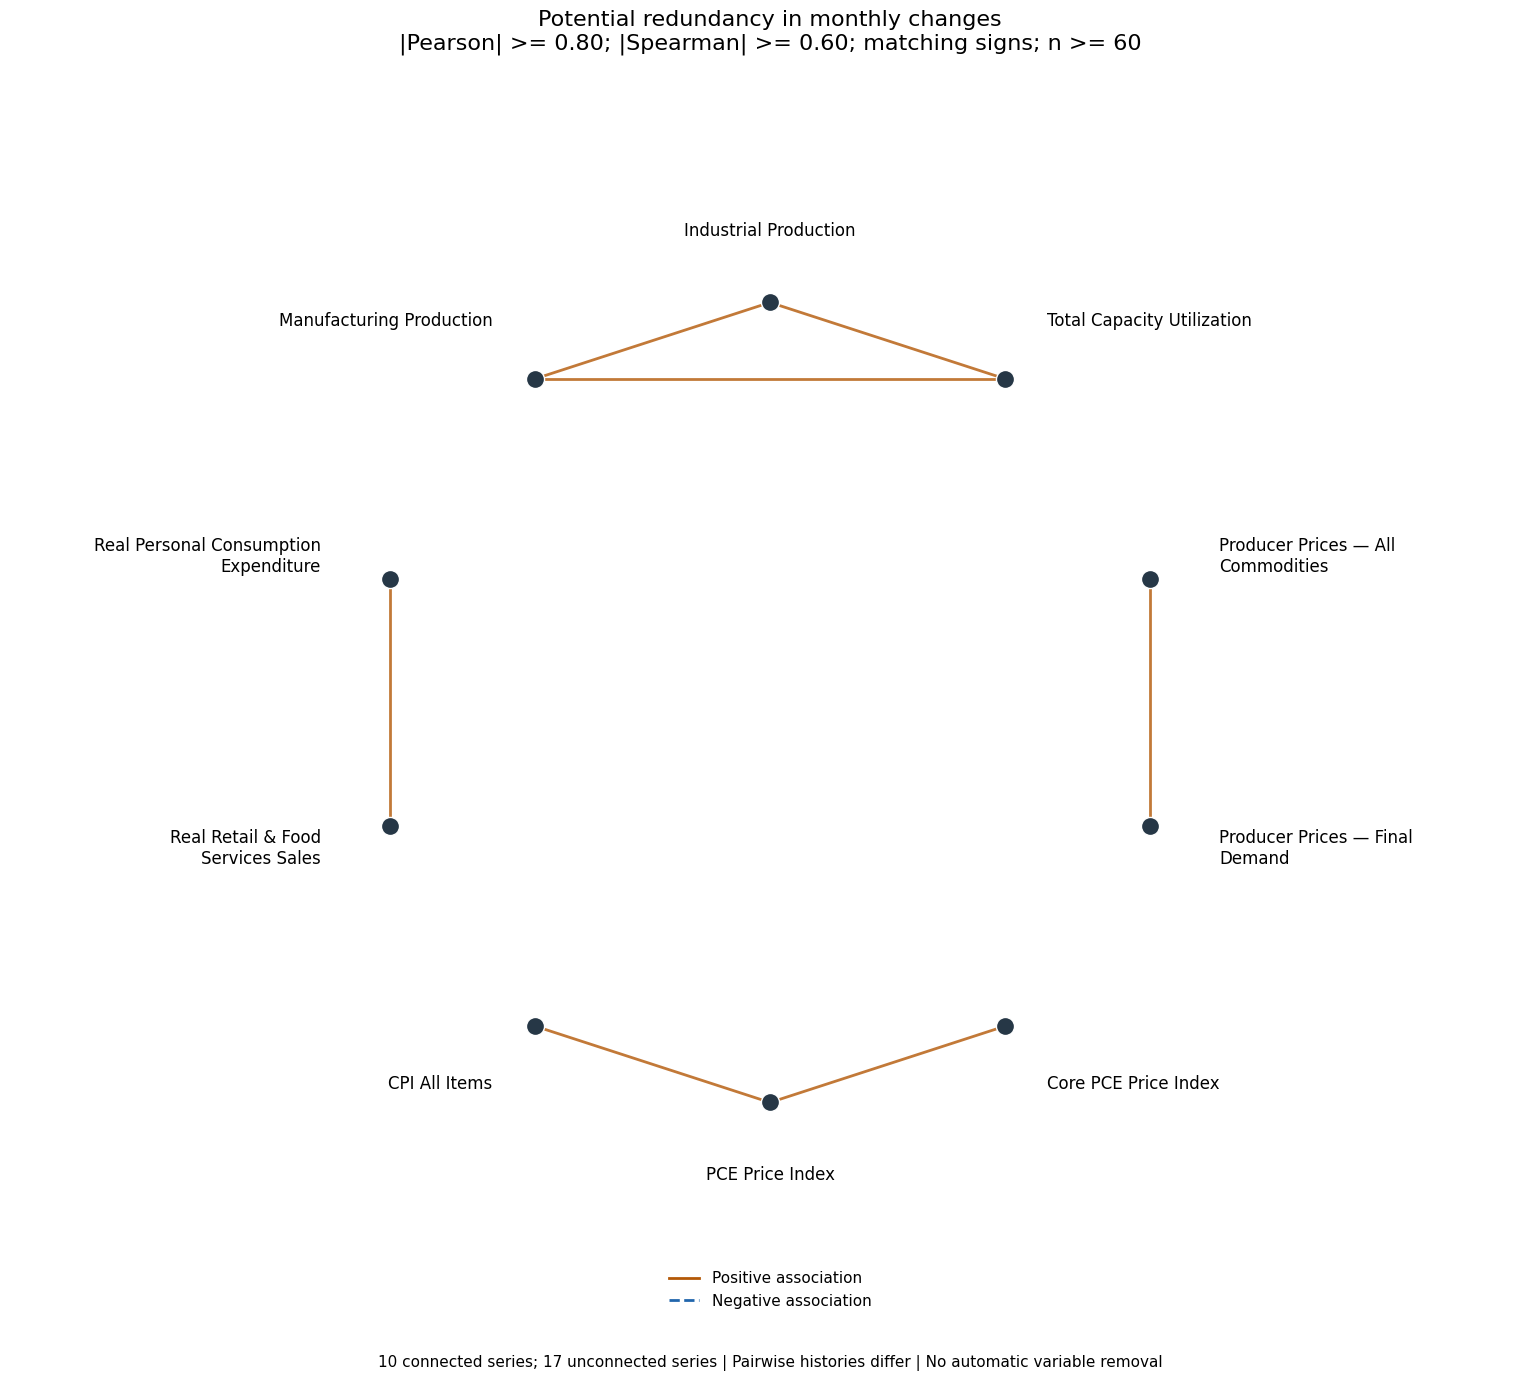

In [9]:
from matplotlib.lines import Line2D
connected=[sid for sid in series_ids if sid in set(candidates.variable_1) | set(candidates.variable_2)]
fig,ax=plt.subplots(figsize=(17,14))
if connected:
    angles=np.linspace(0,2*np.pi,len(connected),endpoint=False)+np.pi/2
    positions={sid:np.array([np.cos(a),np.sin(a)]) for sid,a in zip(connected,angles)}
    for row in candidates.itertuples(index=False):
        a,b=positions[row.variable_1],positions[row.variable_2]
        ax.plot([a[0],b[0]],[a[1],b[1]],color='#B35806' if row.pearson>0 else '#2166AC',
                linestyle='-' if row.pearson>0 else '--',linewidth=2,alpha=.8,zorder=1)
    for sid,pos in positions.items():
        ax.scatter(*pos,s=170,color='#263746',edgecolor='white',zorder=3)
        textpos=pos*1.18
        ax.text(*textpos,textwrap.fill(DISPLAY_NAMES[sid],26),ha='left' if pos[0]>.1 else 'right' if pos[0]<-.1 else 'center',
                va='center',fontsize=12,bbox={'facecolor':'white','edgecolor':'none','alpha':.9})
else:
    ax.text(.5,.5,'No pairs meet the selected thresholds',transform=ax.transAxes,ha='center')
ax.set(xlim=(-1.9,1.9),ylim=(-1.55,1.55))
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Potential redundancy in monthly changes\n|Pearson| >= {PEARSON_THRESHOLD:.2f}; |Spearman| >= {SPEARMAN_THRESHOLD:.2f}; matching signs; n >= {MIN_PERIODS}',pad=24)
ax.legend(handles=[Line2D([0],[0],color='#B35806',lw=2,label='Positive association'),
                   Line2D([0],[0],color='#2166AC',lw=2,ls='--',label='Negative association')],loc='lower center',frameon=False)
fig.text(.5,.02,f'{len(connected)} connected series; {len(series_ids)-len(connected)} unconnected series | Pairwise histories differ | No automatic variable removal',ha='center')
fig.tight_layout(rect=[0,.04,1,1]); save_figure(fig,'redundancy_map.png')

### Screened correlation matrix and series-level coverage

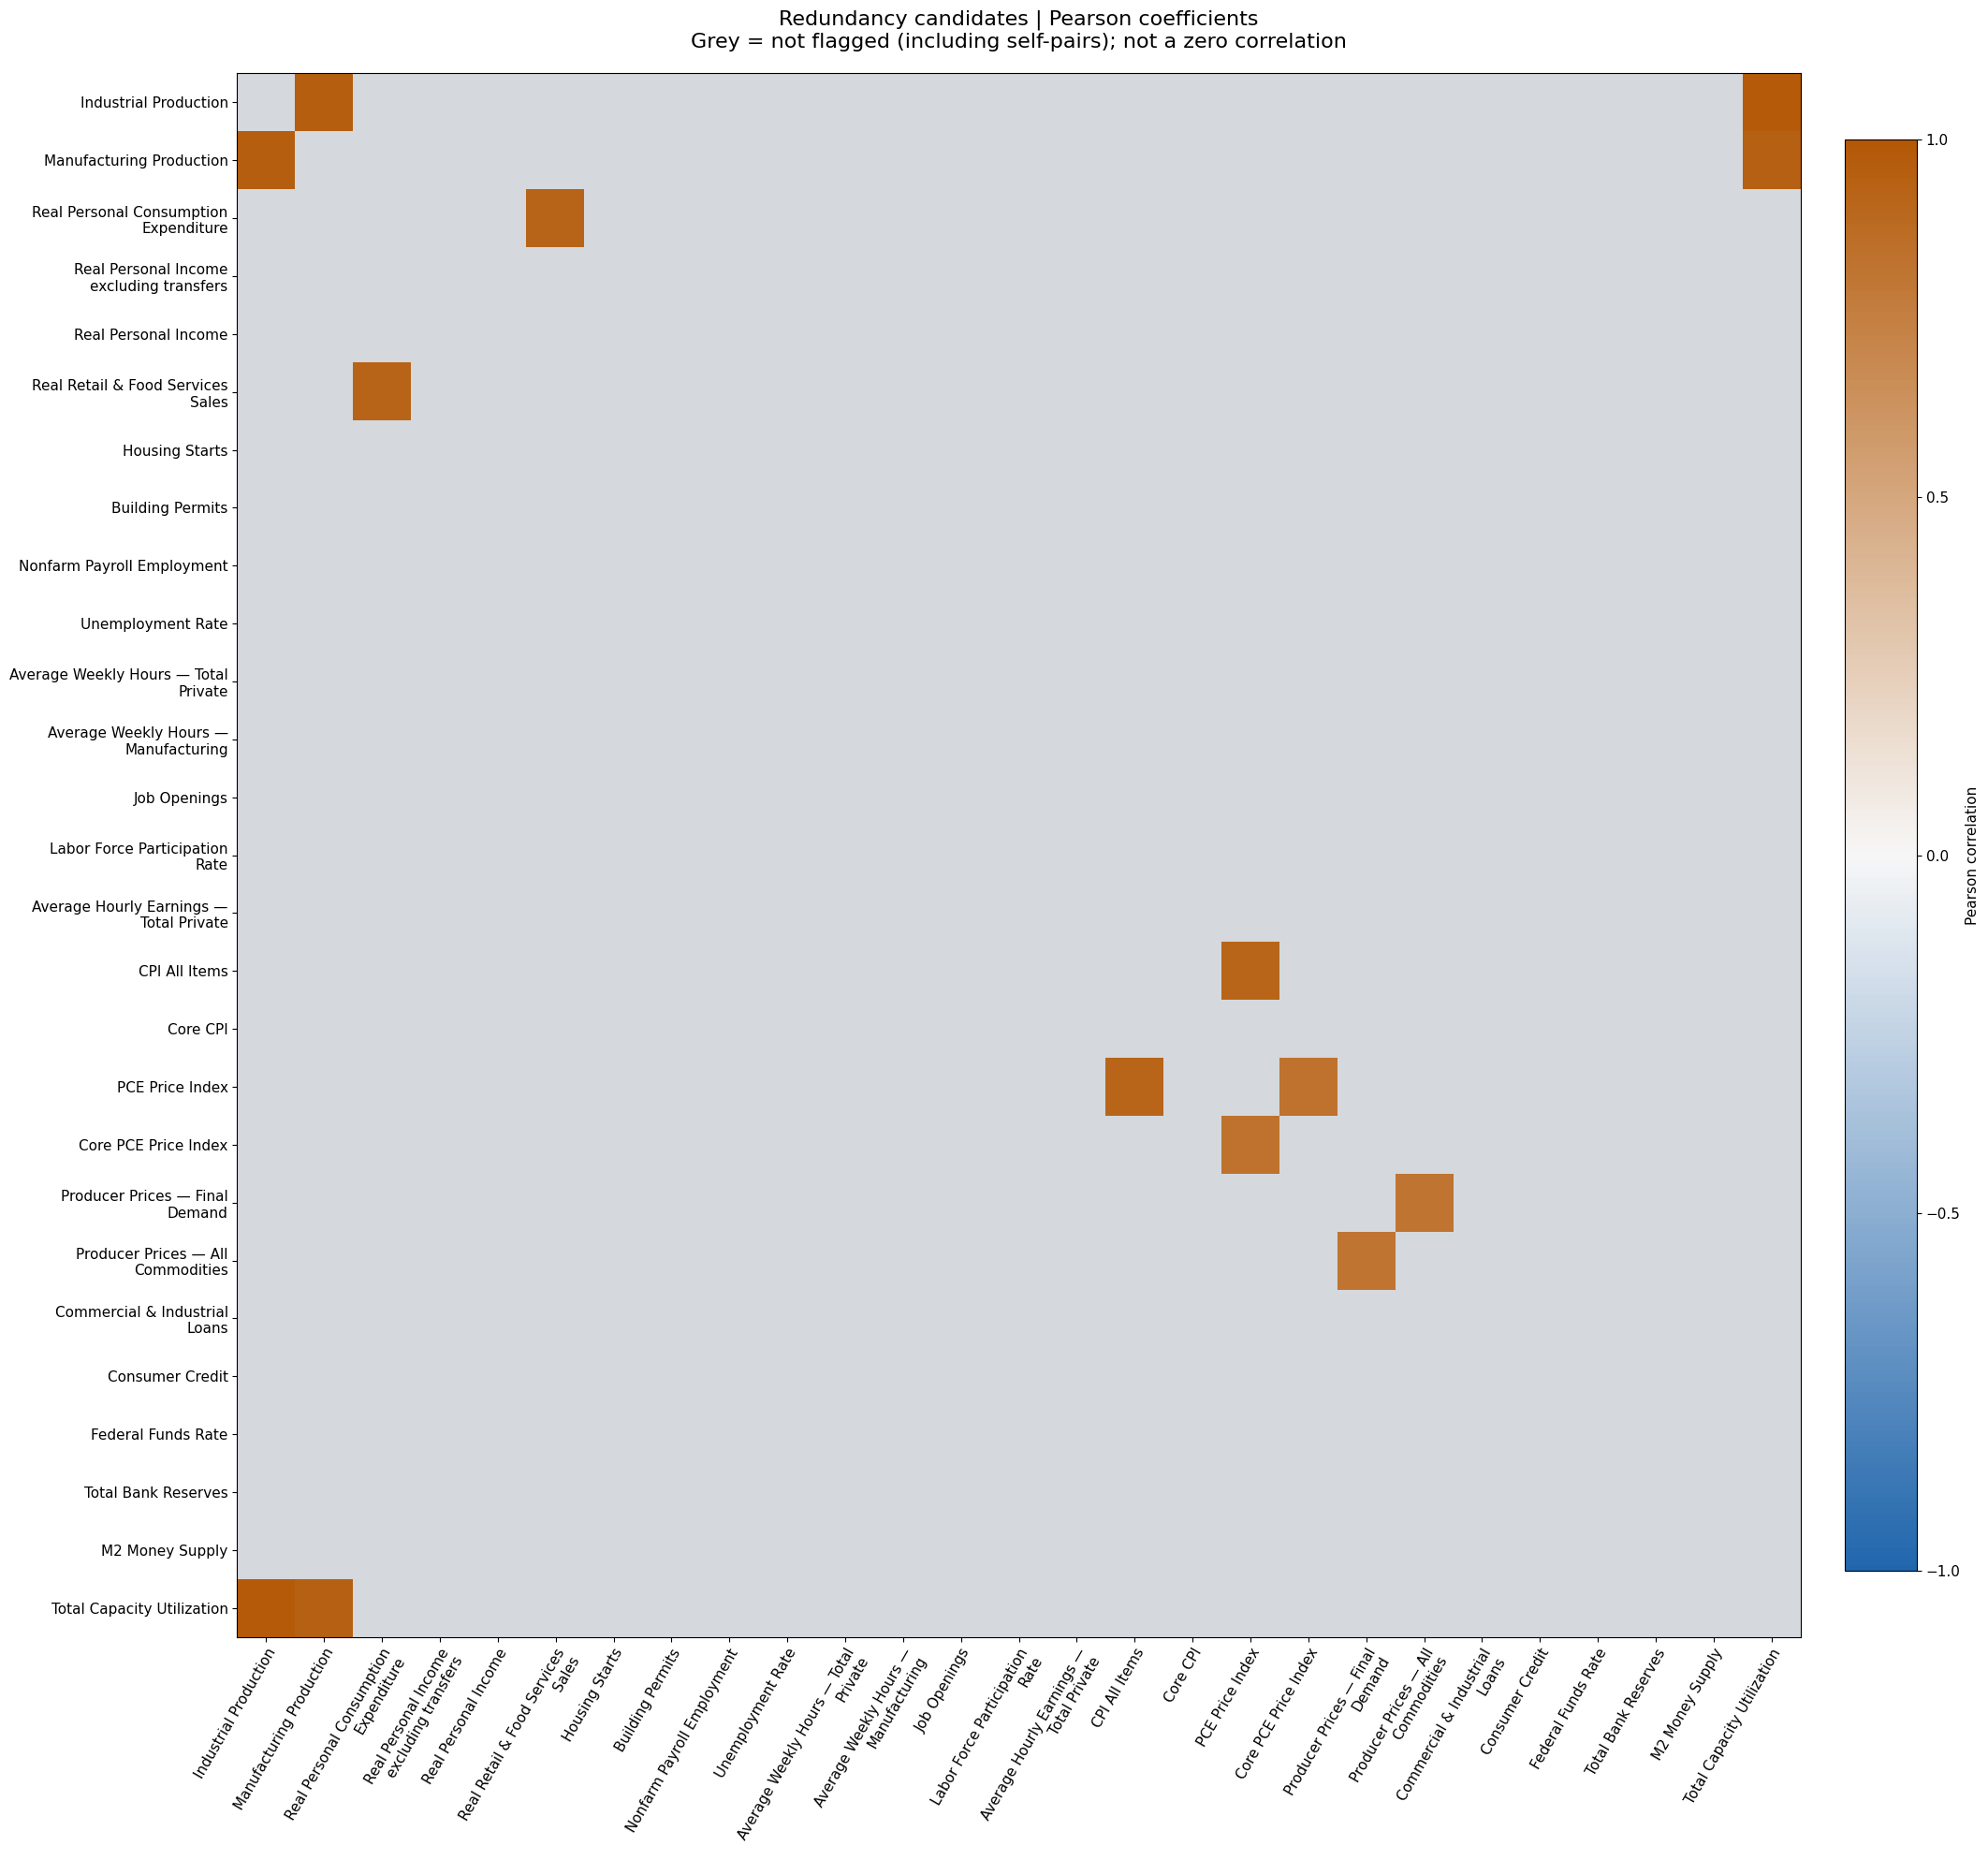

Dataset,Category,Candidate connections
Industrial Production,Growth / Activity,2
Manufacturing Production,Growth / Activity,2
Real Personal Consumption Expenditure,Growth / Activity,1
Real Personal Income excluding transfers,Growth / Activity,0
Real Personal Income,Growth / Activity,0
Real Retail & Food Services Sales,Growth / Activity,1
Housing Starts,Growth / Activity,0
Building Permits,Growth / Activity,0
Nonfarm Payroll Employment,Labor,0
Unemployment Rate,Labor,0


In [10]:
mask=pd.DataFrame(False,index=series_ids,columns=series_ids)
for row in candidates.itertuples(index=False):
    mask.loc[row.variable_1,row.variable_2]=mask.loc[row.variable_2,row.variable_1]=True
screened=pearson_matrix.where(mask)
fig,ax=plt.subplots(figsize=(22,20))
im=ax.imshow(np.ma.masked_invalid(screened.to_numpy()),cmap=SIGNED_COLORS,vmin=-1,vmax=1)
titles=[textwrap.fill(DISPLAY_NAMES[sid],28) for sid in series_ids]
ax.set_xticks(range(len(titles)),labels=titles,rotation=60,ha='right',rotation_mode='anchor',fontsize=11)
ax.set_yticks(range(len(titles)),labels=titles,fontsize=11)
ax.set_title('Redundancy candidates | Pearson coefficients\nGrey = not flagged (including self-pairs); not a zero correlation',pad=20)
fig.colorbar(im,ax=ax,fraction=.04,pad=.025,label='Pearson correlation',ticks=[-1,-.5,0,.5,1])
fig.tight_layout(); save_figure(fig,'screened_correlations.png')
series_summary=pd.DataFrame([{'series_id':sid,'category':category_lookup[sid],
    'candidate_connections':int((candidates.variable_1.eq(sid)|candidates.variable_2.eq(sid)).sum())} for sid in series_ids])
save_table(series_summary,'series_connections.csv',index=False)
display_report(series_summary)

## Checks & Takeaways

In [11]:
assert len(pairs)==len(series_ids)*(len(series_ids)-1)//2
assert np.allclose(pearson_matrix,pearson_matrix.T,equal_nan=True)
assert int(mask.to_numpy().sum())==2*len(candidates)
for row in candidates.itertuples(index=False):
    paired=monthly_change[[row.variable_1,row.variable_2]].dropna()
    assert np.isclose(np.corrcoef(paired.to_numpy().T)[0,1],row.pearson)
    assert len(paired)==row.overlapping_observations and len(paired)>=MIN_PERIODS
summary={'monthly_series':len(series_ids),'screened_pairs':len(pairs),'candidate_pairs':len(candidates),
         'connected_series':len(connected),'unconnected_series':len(series_ids)-len(connected),
         'strong_pearson_pairs_failing_rank_screen':len(pearson_only),
         'frequency_exclusions':', '.join(excluded_frequency.series_id.map(DISPLAY_NAMES)),
         'interpretation':'Candidates warrant joint economic review; correlated series are not automatically interchangeable.'}
finish(summary,{'min_observations':MIN_PERIODS,'absolute_pearson':PEARSON_THRESHOLD,'absolute_spearman':SPEARMAN_THRESHOLD,'matching_signs':True})

- **Monthly series:** 27
- **Screened pairs:** 351
- **Candidate pairs:** 7
- **Connected series:** 10
- **Unconnected series:** 17
- **Strong pearson pairs failing rank screen:** 4
- **Frequency exclusions:** Initial Claims, SLOOS: Banks Tightening C&I Lending Standards, SLOOS: Stronger Demand for C&I Loans, Delinquency Rate on Business Loans, Reserve Balances with Federal Reserve Banks, Federal Reserve Total Assets, Real Exports of Goods and Services, Real Imports of Goods and Services, Nonfarm Business Sector Labor Productivity
- **Interpretation:** Candidates warrant joint economic review; correlated series are not automatically interchangeable.

Input hashes verified unchanged. Exports: C:\Users\HYPE AMD\Desktop\CHronoZ-Economic-Modelling\outputs\redundancy
